In [2]:
from sklearn.datasets import make_classification

In [3]:
# Model training
from sklearn.linear_model import LogisticRegression
logistic = LogisticRegression()

In [4]:
X,y = make_classification(
  n_samples=1000,
  n_classes=2,
  random_state=1
)

In [5]:
# Train-Test split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.25, random_state=0)

In [6]:
## roc curve ans auc
from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score

from matplotlib import pyplot

In [9]:
# generate a no skill prediction (majority class)  : dummy model 0 as output
dummy_model_prob = [0 for _ in range(len(y_test))]
dummy_model_prob

[0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,


In [10]:
model = LogisticRegression()
model.fit(X_train, y_train)

LogisticRegression()

In [17]:
# prediction based on probability
model_prob = model.predict_proba(X_test)

In [18]:
model_prob

array([[0.04313941, 0.95686059],
       [0.08126441, 0.91873559],
       [0.96935458, 0.03064542],
       ...,
       [0.99109431, 0.00890569],
       [0.1370837 , 0.8629163 ],
       [0.94083051, 0.05916949]])

In [19]:
# let's focus on positive outcome
model_prob = model_prob[:,1]

In [20]:
# let's calculate the scores
dummy_model_auc = roc_auc_score(y_test, dummy_model_prob)
model_auc=roc_auc_score(y_test, model_prob)
print(dummy_model_auc)
print(model_auc)

0.5
0.9028805120910384


In [28]:
 ## calculate ROC curves
dummy_fpr, dummy_tpr, _ = roc_curve(y_test, dummy_model_prob)
model_fpr, model_tpr, thresholds = roc_curve(y_test, model_prob)

In [29]:
thresholds

array([           inf, 9.99960704e-01, 9.87264301e-01, 9.86997529e-01,
       9.81153454e-01, 9.80811692e-01, 9.64814516e-01, 9.64704044e-01,
       9.64683305e-01, 9.63978981e-01, 9.56077792e-01, 9.54983233e-01,
       9.51259325e-01, 9.50281404e-01, 9.47728387e-01, 9.46739017e-01,
       9.42792013e-01, 9.42658918e-01, 9.40665563e-01, 9.40126914e-01,
       9.36025834e-01, 9.35947995e-01, 9.30041530e-01, 9.27128048e-01,
       9.19641933e-01, 9.18836271e-01, 9.16985876e-01, 9.16793288e-01,
       9.11803206e-01, 9.10331630e-01, 9.01416579e-01, 9.01315224e-01,
       8.74254337e-01, 8.72321258e-01, 8.62428752e-01, 8.62345711e-01,
       8.59567954e-01, 8.57925156e-01, 8.52227565e-01, 8.46889126e-01,
       8.43875911e-01, 8.42226314e-01, 8.40056794e-01, 8.39449435e-01,
       8.37732215e-01, 8.37604237e-01, 8.31258102e-01, 8.30293844e-01,
       8.29706499e-01, 8.28958927e-01, 8.15502119e-01, 8.13315372e-01,
       8.12537640e-01, 8.10647109e-01, 8.09917749e-01, 8.07856662e-01,
      

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


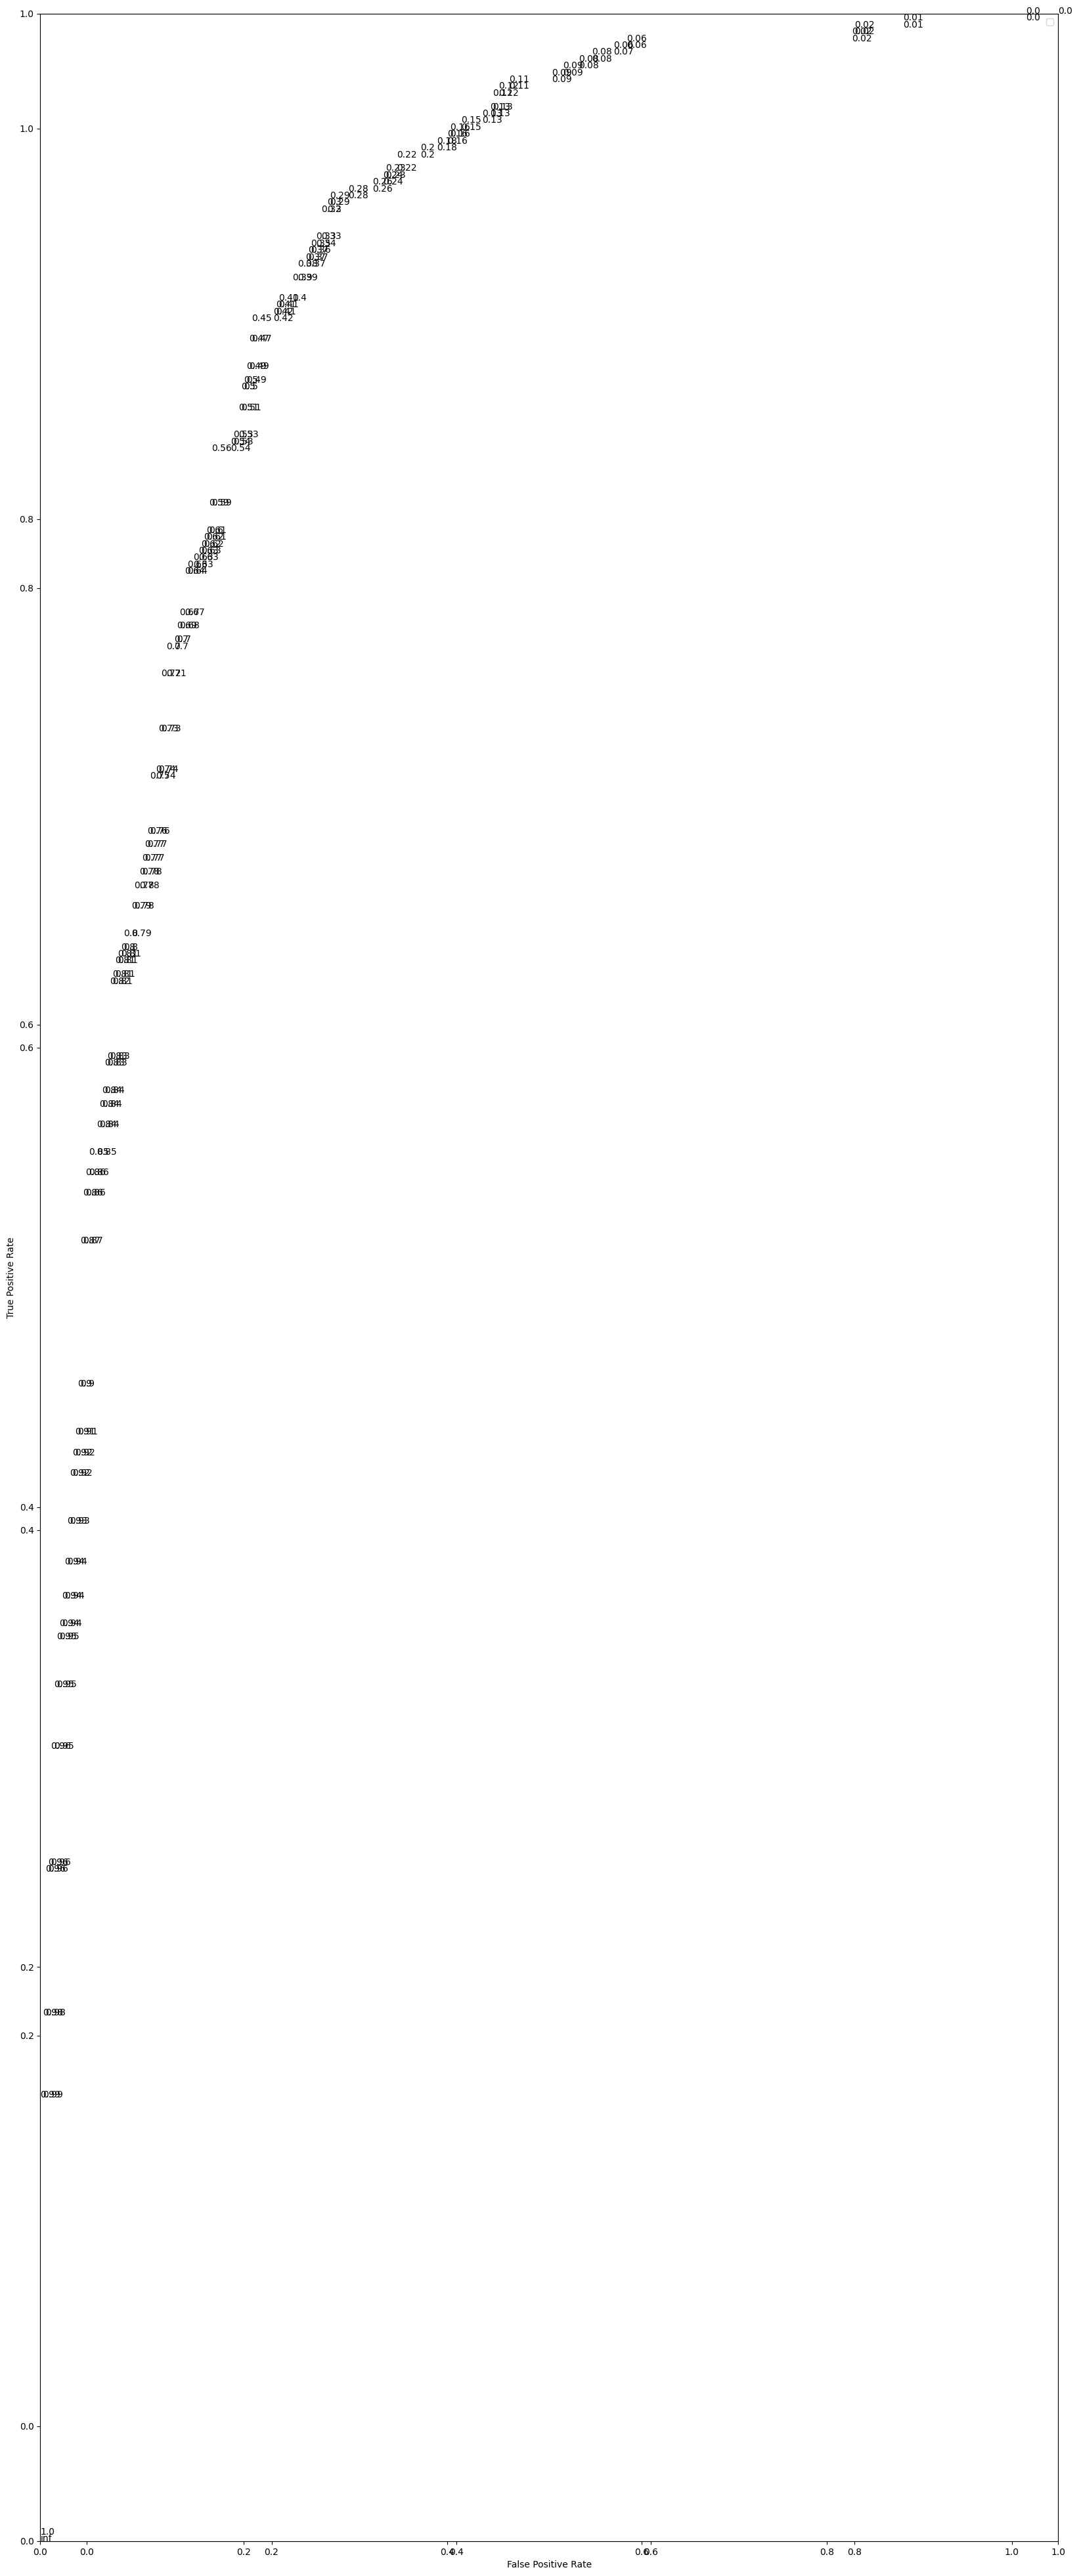

In [31]:
# plot roc curve
import numpy as np
fig = pyplot.figure(figsize=(20,50))
pyplot.plot(dummy_fpr, dummy_tpr, linestyle="--", label='Dummy Model')
pyplot.plot(model_fpr, model_tpr, marker=".", label='Logisitc')

ax = fig.add_subplot(111)
for xyz in zip(model_fpr, model_tpr, thresholds):
  ax.annotate('%s' % np.round(xyz[2], 2), xy=(xyz[0], xyz[1]))

pyplot.xlabel('False Positive Rate')
pyplot.ylabel('True Positive Rate')

pyplot.legend()

pyplot.show()
